# Lecture 06: 3-Qubit QFT Intuition

> **Motivating question:** How much of the Quantum Fourier Transform can we already understand by unpacking one carefully chosen 3-qubit circuit by hand?

**Learning goals**
- see why 3 qubits are already enough to reveal the main QFT pattern
- connect the general QFT formula to the concrete 3-qubit case
- understand how basis labels become structured phase patterns
- read the 3-qubit QFT circuit gate by gate
- track how Hadamards and controlled-phase gates accumulate phase
- use Bloch-sphere intuition honestly: locally when it is exact, cautiously when it is only partial
- understand why the final swaps appear and how they affect output ordering
- verify that the final state matches the QFT formula, a manual circuit, and the library implementation

**Roadmap**
1. Why 3 qubits are enough
2. QFT recap: general definition and 3-qubit specialization
3. Basis-state action and phase ramps
4. The 3-qubit circuit at a glance
5. Step-by-step walkthrough for one input state
6. Bloch-sphere intuition and its limits
7. Formula vs circuit vs library agreement
8. Misconceptions, summary, and follow-up prompts

This is a **lecture notebook**, not a worksheet. The emphasis is on continuity between formula, circuit, and geometry rather than on scaffolded exercises.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.patches import Rectangle
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import DensityMatrix, Operator, Statevector, partial_trace
from qiskit.visualization import plot_bloch_vector

from utilities.complexity_utils import COLORS, setup_lecture_style

setup_lecture_style()
plt.rcParams['figure.max_open_warning'] = 0
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.titlepad'] = 10
np.set_printoptions(precision=3, suppress=True)


def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def basis_ket(num_qubits, index):
    vector = np.zeros(2**num_qubits, dtype=complex)
    vector[index] = 1.0
    return vector


def qft_matrix(num_qubits):
    dimension = 2**num_qubits
    omega = np.exp(2j * np.pi / dimension)
    return np.array(
        [[omega ** (row * col) for col in range(dimension)] for row in range(dimension)],
        dtype=complex,
    ) / np.sqrt(dimension)


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


def plot_state_magnitude_phase(ax_mag, ax_phase, state, labels, *, color=COLORS['navy'], title=''):
    data = np.asarray(state, dtype=complex)
    x = np.arange(len(labels))

    ax_mag.bar(x, np.abs(data), color=color)
    ax_mag.set_xticks(x, labels, rotation=35)
    ax_mag.set_ylim(0, 1.05)
    ax_mag.set_ylabel('magnitude')
    ax_mag.set_title(title, loc='left', fontsize=13)

    ax_phase.bar(x, phase_degrees(data), color=color)
    ax_phase.set_xticks(x, labels, rotation=35)
    ax_phase.set_ylim(-20, 380)
    ax_phase.set_yticks([0, 90, 180, 270, 360])
    ax_phase.set_ylabel('phase (degrees)')


PAULI_X = np.array([[0, 1], [1, 0]], dtype=complex)
PAULI_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
PAULI_Z = np.array([[1, 0], [0, -1]], dtype=complex)


def reduced_single_qubit_density(state, qubit):
    num_qubits = int(np.log2(len(state.data)))
    trace_out = [index for index in range(num_qubits) if index != qubit]
    return partial_trace(state, trace_out)


def bloch_xyz(state, qubit):
    rho = DensityMatrix(reduced_single_qubit_density(state, qubit)).data
    x = np.real(np.trace(rho @ PAULI_X))
    y = np.real(np.trace(rho @ PAULI_Y))
    z = np.real(np.trace(rho @ PAULI_Z))
    return np.array([x, y, z], dtype=float)


def reduced_purity(state, qubit):
    rho = DensityMatrix(reduced_single_qubit_density(state, qubit)).data
    return float(np.real(np.trace(rho @ rho)))


def display_bloch_row(state, *, qubits=(2, 1, 0), title='', exact_note=''):
    fig = plt.figure(figsize=(11.8, 3.6), constrained_layout=True)
    for column, qubit in enumerate(qubits, start=1):
        ax = fig.add_subplot(1, len(qubits), column, projection='3d')
        plot_bloch_vector(
            bloch_xyz(state, qubit),
            title=f'q{qubit}',
            ax=ax,
            coord_type='cartesian',
            font_size=10,
        )
    if title:
        fig.suptitle(title, x=0.03, ha='left')
    if exact_note:
        fig.text(0.03, 0.03, exact_note, color=COLORS['gray'], fontsize=10.5)
    display(fig)
    plt.close(fig)


def align_global_phase(reference, trial):
    reference = np.asarray(reference, dtype=complex)
    trial = np.asarray(trial, dtype=complex)
    pivot = np.argmax(np.abs(reference))
    if np.abs(reference[pivot]) < 1e-12:
        return trial
    phase = trial[pivot] / reference[pivot]
    return trial / phase


## 1. Why 3 Qubits Are Enough

**Concept question:** Why stop at 3 qubits if the QFT is defined for any number of qubits?

Because 3 qubits are the smallest case where the whole pattern becomes visible at once.

- With **1 qubit**, the QFT is just a Hadamard. Useful, but structurally too small.
- With **2 qubits**, one controlled-phase gate appears, so the phase story starts, but only one nontrivial angle shows up.
- With **3 qubits**, we finally see:
  - two different controlled-phase angles,
  - binary-fraction phase structure,
  - and the need for a final swap to restore conventional output order.

So 3 qubits are not a toy in the dismissive sense. They are the smallest example that already contains the real QFT architecture.


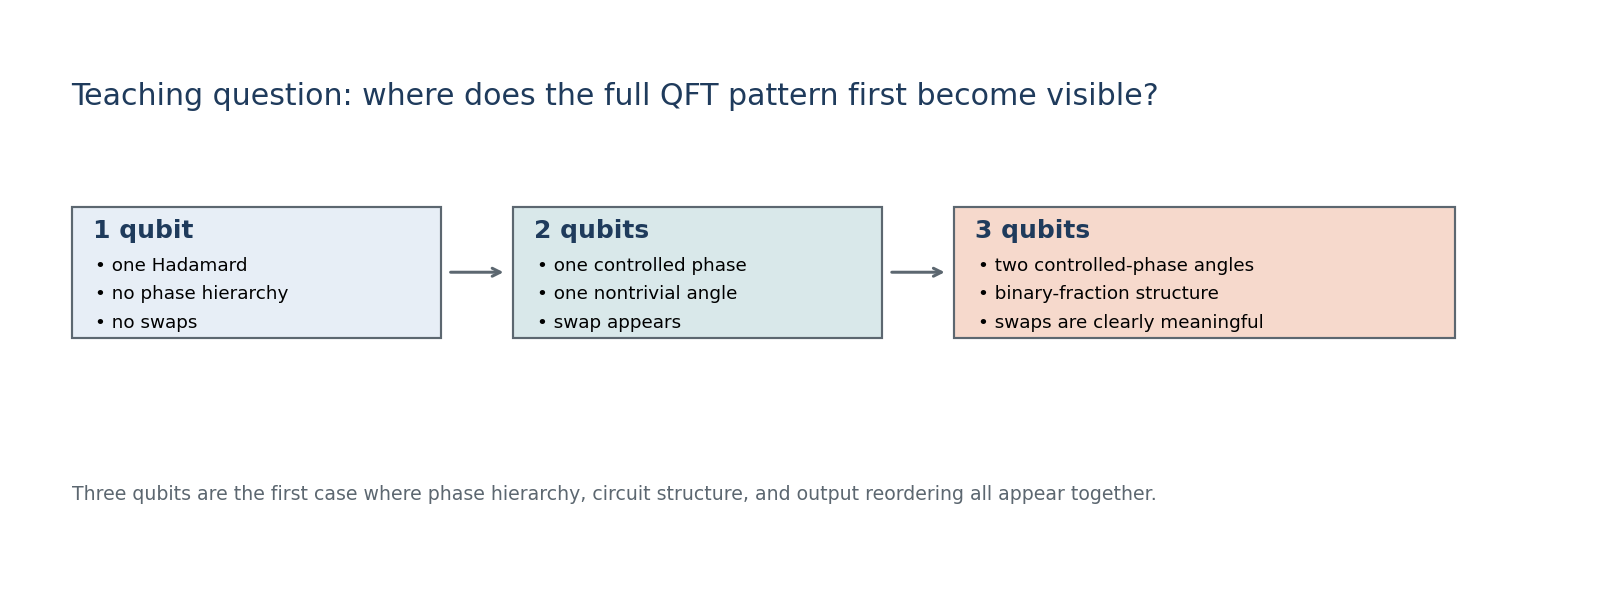

In [2]:
fig, ax = plt.subplots(figsize=(13.2, 4.8), constrained_layout=True)
ax.set_xlim(0, 13.2)
ax.set_ylim(0, 5.2)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

panels = [
    (0.5, 2.2, 3.1, 1.2, '1 qubit', ['one Hadamard', 'no phase hierarchy', 'no swaps'], '#e7eef6'),
    (4.2, 2.2, 3.1, 1.2, '2 qubits', ['one controlled phase', 'one nontrivial angle', 'swap appears'], '#d9e8ea'),
    (7.9, 2.2, 4.2, 1.2, '3 qubits', ['two controlled-phase angles', 'binary-fraction structure', 'swaps are clearly meaningful'], '#f6d9cc'),
]

for x0, y0, w, h, title, bullets, color in panels:
    rect = Rectangle((x0, y0), w, h, facecolor=color, edgecolor=COLORS['gray'], linewidth=1.3)
    ax.add_patch(rect)
    ax.text(x0 + 0.18, y0 + 0.92, title, fontsize=15, color=COLORS['navy'], fontweight='semibold')
    for row, bullet in enumerate(bullets):
        ax.text(x0 + 0.2, y0 + 0.62 - 0.26 * row, f'• {bullet}', fontsize=11)

for x0, x1 in [(3.65, 4.15), (7.35, 7.85)]:
    ax.annotate('', xy=(x1, 2.8), xytext=(x0, 2.8), arrowprops={'arrowstyle': '->', 'linewidth': 1.8, 'color': COLORS['gray']})

ax.text(0.5, 4.35, 'Teaching question: where does the full QFT pattern first become visible?', fontsize=18, color=COLORS['navy'])
ax.text(0.5, 0.72, 'Three qubits are the first case where phase hierarchy, circuit structure, and output reordering all appear together.', fontsize=11.3, color=COLORS['gray'])
plt.show()


> **Takeaway:** Three qubits are the smallest case where QFT stops looking like an isolated trick and starts looking like a real scalable pattern.


## 2. QFT Recap: From the General Definition to the 3-Qubit Case

**Concept question:** What does the abstract QFT formula become when we specialize to 3 qubits?

The general definition on an $N$-dimensional space is
$$

\mathrm{QFT}_N |x\rangle = \frac{1}{\sqrt{N}} \sum_{y=0}^{N-1} e^{2\pi ixy/N}|y\rangle.
$$

For 3 qubits, $N = 8$, so the basis-state action becomes
$$
\mathrm{QFT}_8 |x\rangle = \frac{1}{\sqrt{8}} \sum_{y=0}^{7} e^{2\pi ixy/8}|y\rangle.
$$

The important conceptual change is this:
- before QFT, the information sits in **which computational basis label is occupied**,
- after QFT, the same label appears as a **phase pattern spread across all output labels**.

That is why the circuit will look like a phase-engineering circuit rather than a probability-moving circuit.


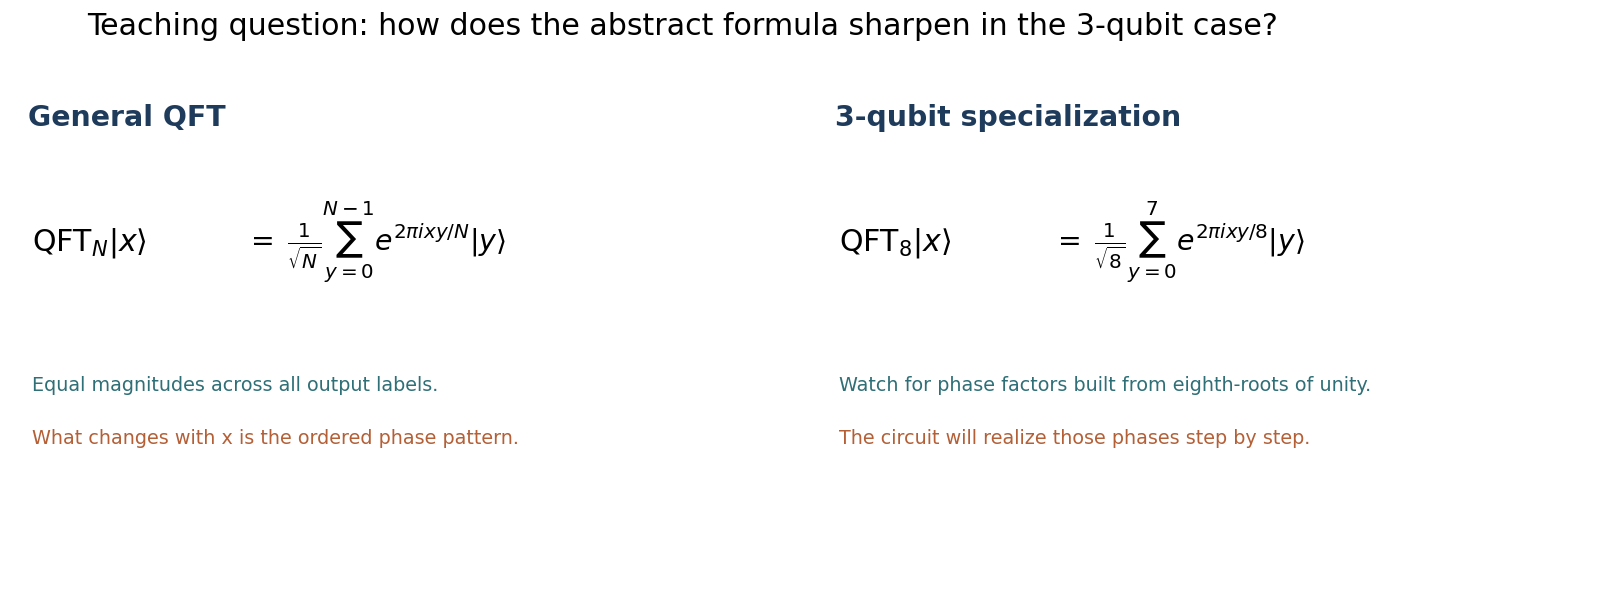

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9), constrained_layout=True)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 5)
axes[0].text(0.2, 4.3, 'General QFT', fontsize=17, color=COLORS['navy'], fontweight='semibold')
axes[0].text(0.25, 3.15, r'$\mathrm{QFT}_N |x\rangle$', fontsize=18)
axes[0].text(2.95, 3.15, r'$=\; \frac{1}{\sqrt{N}} \sum_{y=0}^{N-1} e^{2\pi ixy/N}|y\rangle$', fontsize=17)
axes[0].text(0.25, 1.85, 'Equal magnitudes across all output labels.', fontsize=11.5, color=COLORS['teal'])
axes[0].text(0.25, 1.35, 'What changes with x is the ordered phase pattern.', fontsize=11.5, color=COLORS['rust'])

axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 5)
axes[1].text(0.2, 4.3, '3-qubit specialization', fontsize=17, color=COLORS['navy'], fontweight='semibold')
axes[1].text(0.25, 3.15, r'$\mathrm{QFT}_8 |x\rangle$', fontsize=18)
axes[1].text(2.95, 3.15, r'$=\; \frac{1}{\sqrt{8}} \sum_{y=0}^{7} e^{2\pi ixy/8}|y\rangle$', fontsize=17)
axes[1].text(0.25, 1.85, 'Watch for phase factors built from eighth-roots of unity.', fontsize=11.5, color=COLORS['teal'])
axes[1].text(0.25, 1.35, 'The circuit will realize those phases step by step.', fontsize=11.5, color=COLORS['rust'])

fig.suptitle('Teaching question: how does the abstract formula sharpen in the 3-qubit case?', x=0.05, ha='left')
plt.show()


> **Takeaway:** In the 3-qubit case, the full QFT already shows its main identity: equal-magnitude output plus a structured phase rule indexed by the input label.


## 3. QFT on Basis States: Phase Ramps and Structured Superpositions

**Concept question:** What does the QFT actually do to concrete basis states such as $|000\rangle$, $|001\rangle$, and $|101\rangle$?

For basis-state inputs, one feature is immediate:
- every output basis state gets magnitude $1/\sqrt{8}$,
- so the distinguishing content is not the magnitude pattern,
- it is the **phase ramp** across the eight output labels.

This is the cleanest place to see why phase is the main informational content of the QFT.


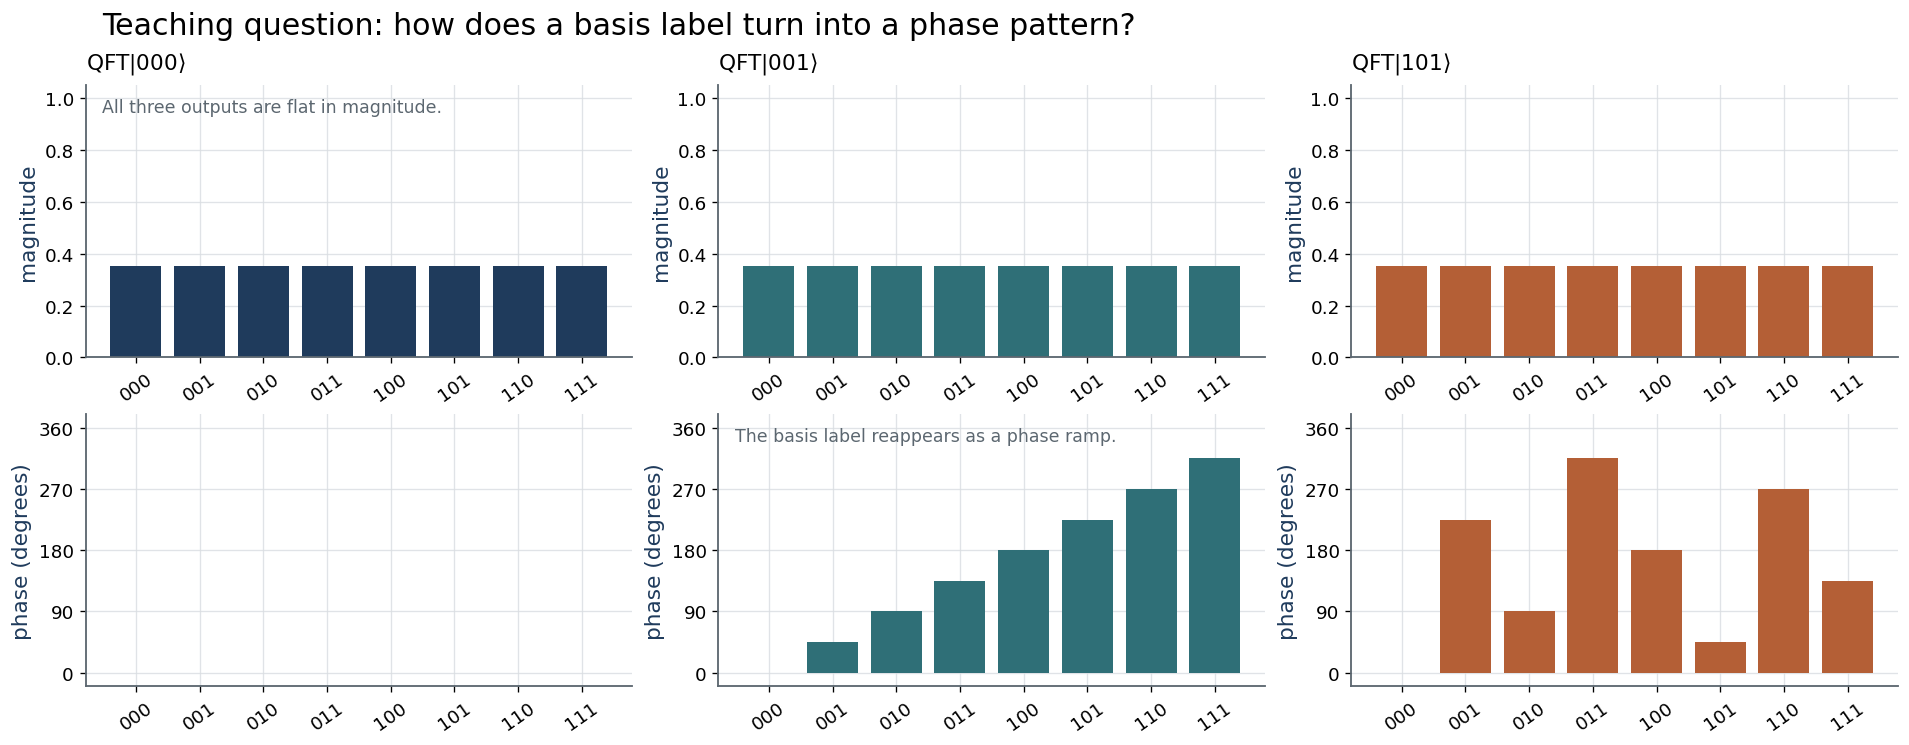

In [4]:
labels_3 = computational_labels(3)
sample_indices = [0, 1, 5]
sample_titles = [r'$\mathrm{QFT}|000\rangle$', r'$\mathrm{QFT}|001\rangle$', r'$\mathrm{QFT}|101\rangle$']
sample_colors = [COLORS['navy'], COLORS['teal'], COLORS['rust']]

fig, axes = plt.subplots(2, 3, figsize=(15.8, 6.1), constrained_layout=True)

for column, (index, title, color) in enumerate(zip(sample_indices, sample_titles, sample_colors)):
    state = Statevector(qft_matrix(3) @ basis_ket(3, index)).data
    plot_state_magnitude_phase(axes[0, column], axes[1, column], state, labels_3, color=color, title=title)

axes[0, 0].text(0.03, 0.9, 'All three outputs are flat in magnitude.', transform=axes[0, 0].transAxes, fontsize=10.4, color=COLORS['gray'])
axes[1, 1].text(0.03, 0.9, 'The basis label reappears as a phase ramp.', transform=axes[1, 1].transAxes, fontsize=10.4, color=COLORS['gray'])

fig.suptitle('Teaching question: how does a basis label turn into a phase pattern?', x=0.05, ha='left')
plt.show()


Read the three columns carefully:

- $|000\rangle$ gives a completely flat phase pattern.
- $|001\rangle$ gives a gentle ramp.
- $|101\rangle$ gives a faster, more structured phase wrap.

The key fact is not that the output is “spread out.” The key fact is **how the phases are ordered across the spread-out output**.

> **Takeaway:** On basis states, the QFT maps “which label is occupied” into “which phase ramp appears across the output labels.”


## 4. The 3-Qubit QFT Circuit at a Glance

**Concept question:** How does the circuit implement that phase rule?

The standard 3-qubit QFT circuit has three gate families, each with a distinct job:

- **Hadamards** create local phase-sensitive superpositions.
- **Controlled-phase gates** add the binary-fraction phase corrections.
- **The final swap** restores the conventional output ordering.

The diagram below is the whole object we will now unpack line by line.


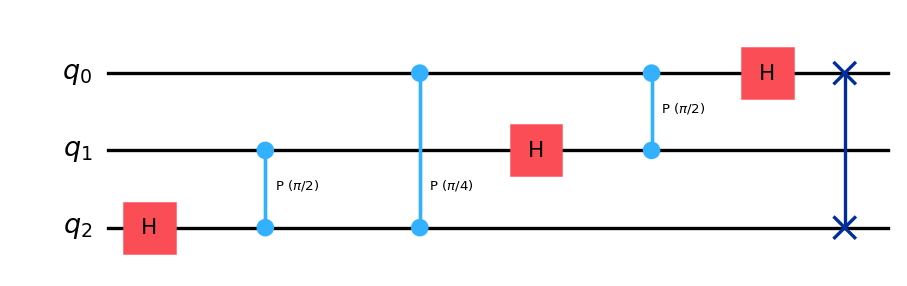

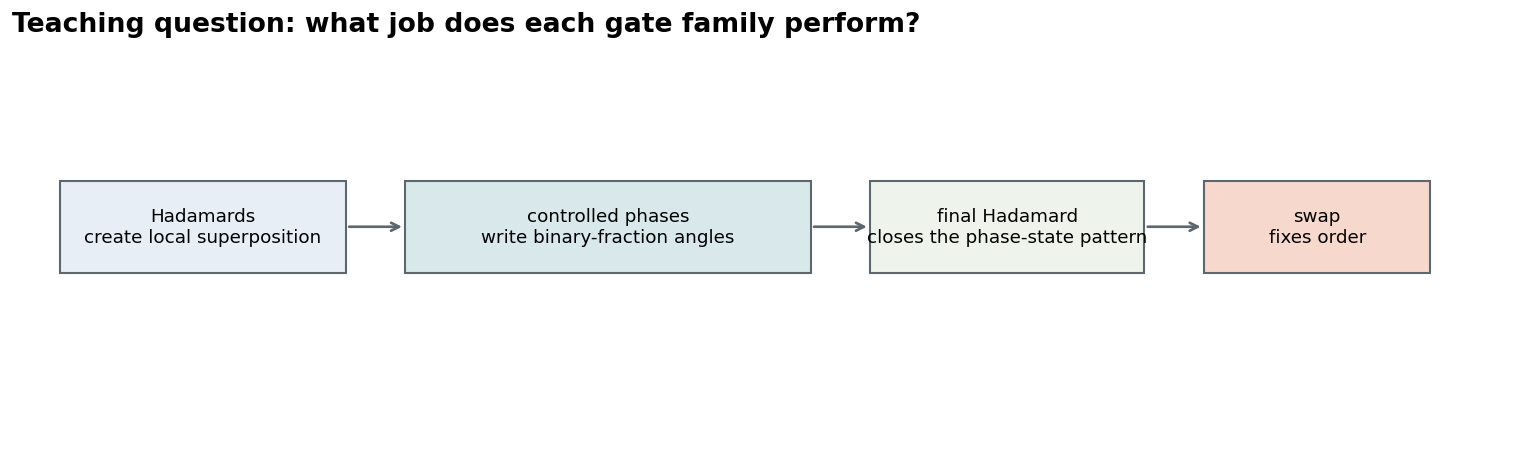

In [5]:
manual_qft_3 = QuantumCircuit(3, name='QFT_3')
manual_qft_3.h(2)
manual_qft_3.cp(np.pi / 2, 1, 2)
manual_qft_3.cp(np.pi / 4, 0, 2)
manual_qft_3.h(1)
manual_qft_3.cp(np.pi / 2, 0, 1)
manual_qft_3.h(0)
manual_qft_3.swap(0, 2)

display(manual_qft_3.draw('mpl'))

fig, ax = plt.subplots(figsize=(12.5, 3.8), constrained_layout=True)
ax.set_xlim(0, 12.5)
ax.set_ylim(0, 4.0)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

boxes = [
    (0.4, 1.8, 2.4, 0.9, 'Hadamards\ncreate local superposition', '#e7eef6'),
    (3.3, 1.8, 3.4, 0.9, 'controlled phases\nwrite binary-fraction angles', '#d9e8ea'),
    (7.2, 1.8, 2.3, 0.9, 'final Hadamard\ncloses the phase-state pattern', '#eef4eb'),
    (10.0, 1.8, 1.9, 0.9, 'swap\nfixes order', '#f6d9cc'),
]

for x0, y0, w, h, text, color in boxes:
    rect = Rectangle((x0, y0), w, h, facecolor=color, edgecolor=COLORS['gray'], linewidth=1.25)
    ax.add_patch(rect)
    ax.text(x0 + w / 2, y0 + h / 2, text, ha='center', va='center', fontsize=11)

for x0, x1 in [(2.8, 3.3), (6.7, 7.2), (9.5, 10.0)]:
    ax.annotate('', xy=(x1, 2.25), xytext=(x0, 2.25), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': COLORS['gray']})

ax.set_title('Teaching question: what job does each gate family perform?', loc='left')
plt.show()


> **Takeaway:** The 3-qubit QFT circuit is not a bag of gates. It is a staged construction of one-qubit phase states plus a final reordering step.


## 5. Walkthrough Setup: Input, Notation, and Tracking Strategy

**Concept question:** What exactly will we track as the circuit evolves?

We will follow one concrete input throughout:
$$
|101\rangle = |1\rangle_2 |0\rangle_1 |1\rangle_0.
$$

Why this choice?
- it is nontrivial,
- both phase angles $\pi/2$ and $\pi/4$ will matter,
- and the final answer is rich enough to show the full pattern without becoming unreadable.

We will track four things at each major step:
- the partial circuit,
- the updated state formula,
- the global magnitude/phase pattern,
- and a Bloch-sphere view of the individual qubits.

For this specific basis-state walkthrough, the Bloch-sphere picture is unusually honest: the global state stays a **product state** throughout the staged construction, so the single-qubit Bloch spheres are exact. Later we will contrast that with a case where they become only reduced local views.


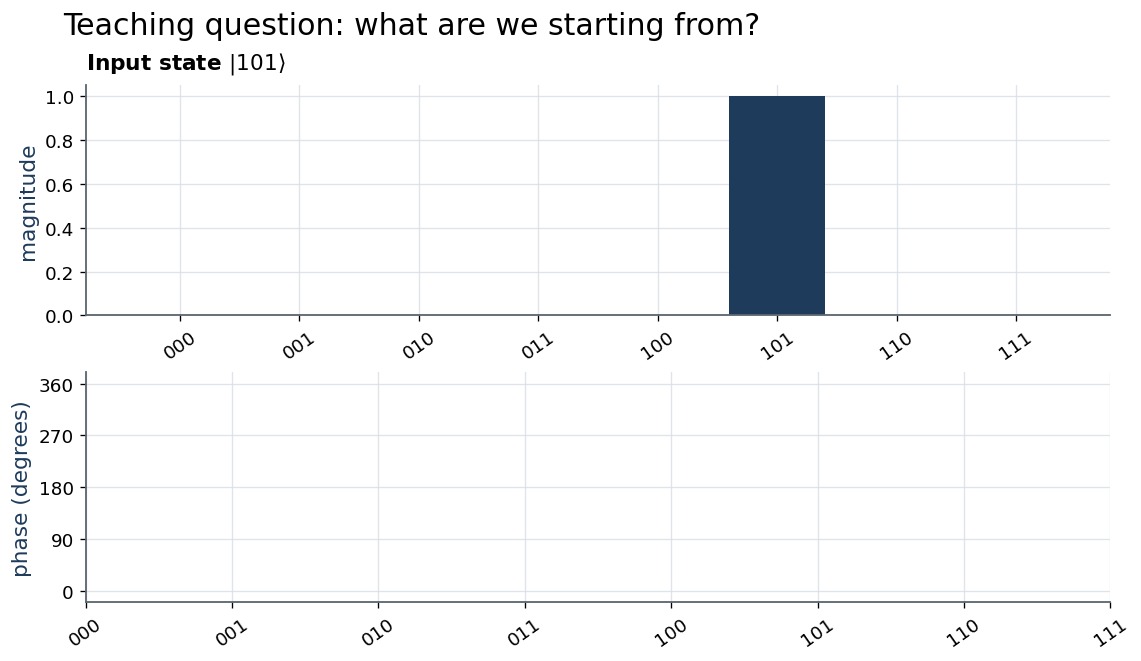

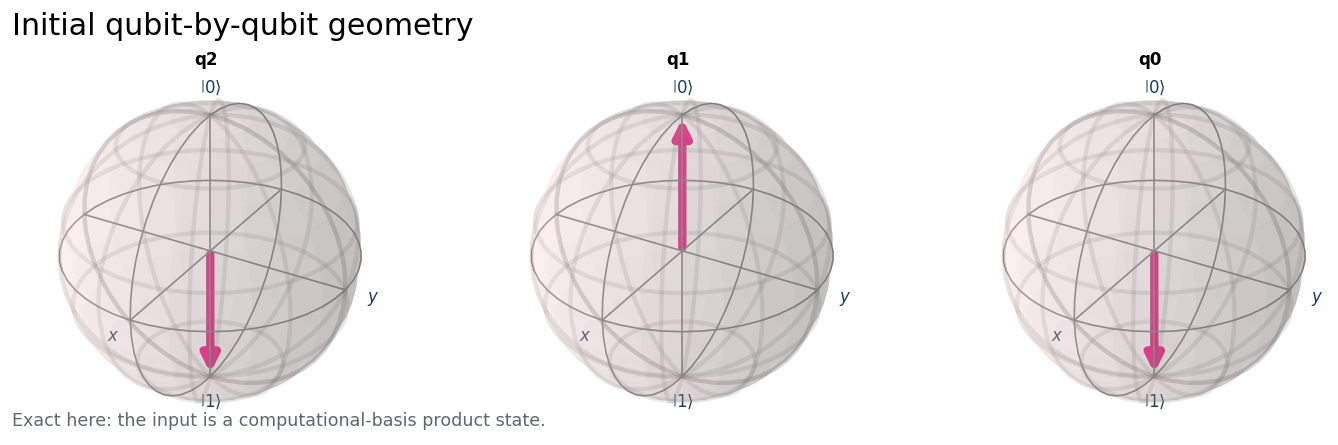

In [6]:
worked_input_label = '101'
worked_input_state = Statevector.from_label(worked_input_label)

qc_step_1 = QuantumCircuit(3, name='step_1')
qc_step_1.h(2)

qc_step_2 = qc_step_1.copy()
qc_step_2.cp(np.pi / 2, 1, 2)
qc_step_2.cp(np.pi / 4, 0, 2)

qc_step_3 = qc_step_2.copy()
qc_step_3.h(1)
qc_step_3.cp(np.pi / 2, 0, 1)

qc_step_4 = qc_step_3.copy()
qc_step_4.h(0)

qc_step_5 = qc_step_4.copy()
qc_step_5.swap(0, 2)

states = {
    'start': worked_input_state,
    'step_1': worked_input_state.evolve(qc_step_1),
    'step_2': worked_input_state.evolve(qc_step_2),
    'step_3': worked_input_state.evolve(qc_step_3),
    'step_4': worked_input_state.evolve(qc_step_4),
    'step_5': worked_input_state.evolve(qc_step_5),
}

fig, axes = plt.subplots(2, 1, figsize=(9.4, 5.4), constrained_layout=True)
plot_state_magnitude_phase(axes[0], axes[1], states['start'].data, labels_3, color=COLORS['navy'], title=r'Input state $|101\rangle$')
fig.suptitle('Teaching question: what are we starting from?', x=0.05, ha='left')
plt.show()

display_bloch_row(
    states['start'],
    title='Initial qubit-by-qubit geometry',
    exact_note='Exact here: the input is a computational-basis product state.'
)


## 6. Step 1: The First Hadamard

**Concept question:** What does the first Hadamard actually create?

The first processed qubit is $q_2$. Since the input bit there is $1$, the Hadamard acts as
$$
H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}.
$$

So the full state becomes
$$
|101\rangle \longrightarrow \frac{|0\rangle - |1\rangle}{\sqrt{2}} \otimes |0\rangle \otimes |1\rangle.
$$

Nothing has yet depended on the other input bits. This step creates the **phase-sensitive canvas** on which later controlled-phase gates will write.


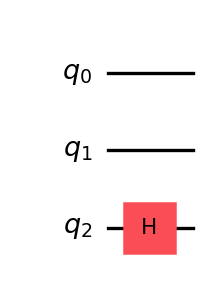

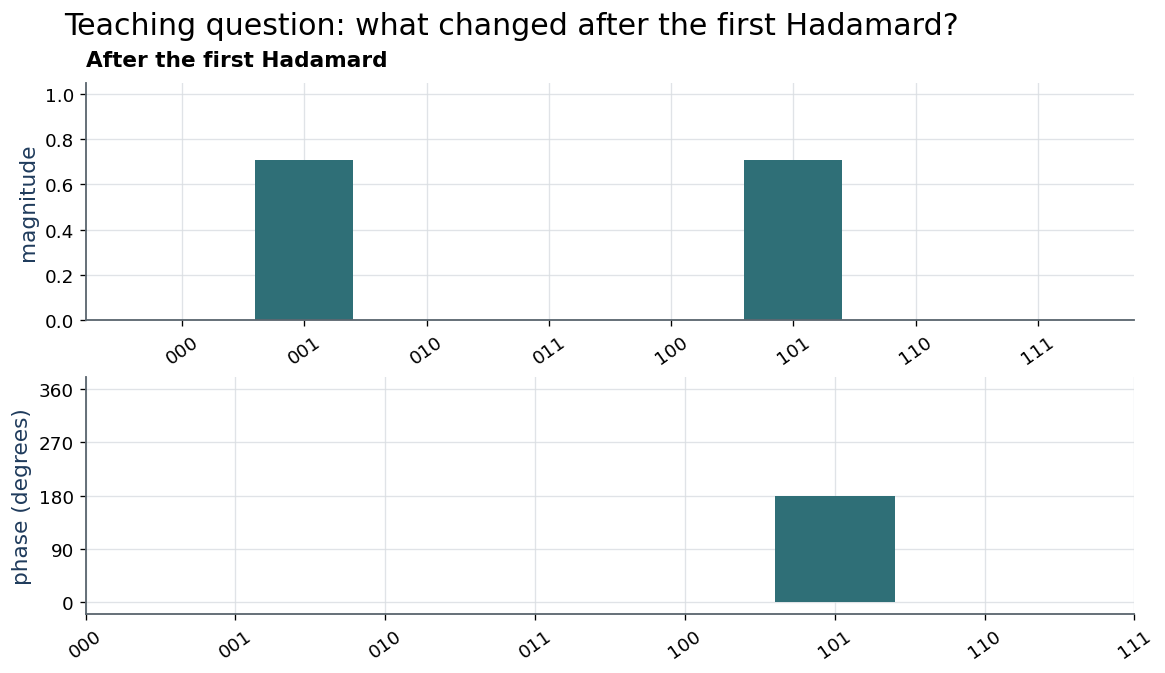

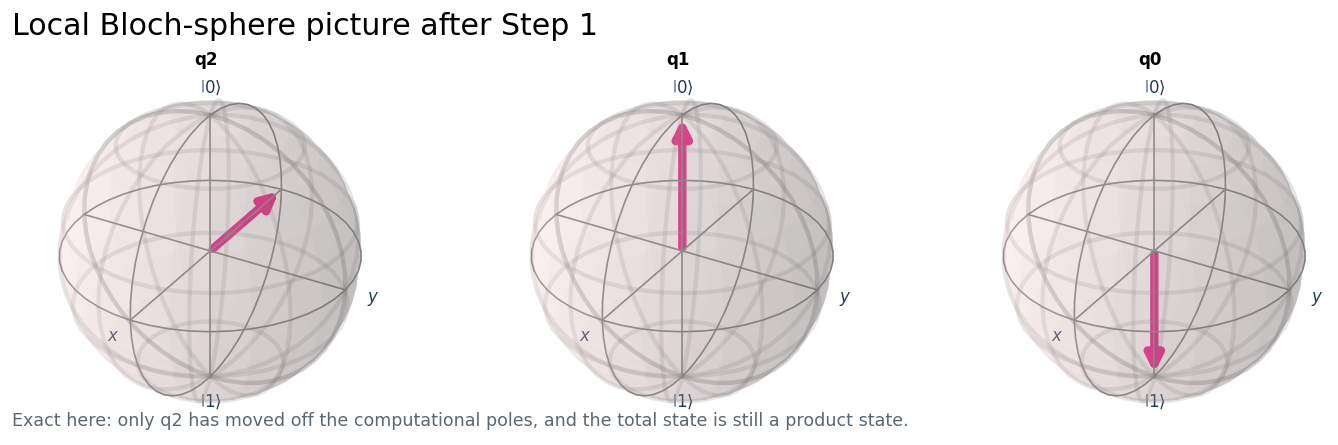

In [7]:
display(qc_step_1.draw('mpl'))

fig, axes = plt.subplots(2, 1, figsize=(9.6, 5.5), constrained_layout=True)
plot_state_magnitude_phase(axes[0], axes[1], states['step_1'].data, labels_3, color=COLORS['teal'], title='After the first Hadamard')
fig.suptitle('Teaching question: what changed after the first Hadamard?', x=0.05, ha='left')
plt.show()

display_bloch_row(
    states['step_1'],
    title='Local Bloch-sphere picture after Step 1',
    exact_note='Exact here: only q2 has moved off the computational poles, and the total state is still a product state.'
)


> **Takeaway:** The first Hadamard does not yet “know” the whole QFT. It creates a local superposition on the qubit whose phase will later be refined.


## 7. Step 2: Controlled-Phase Gates on the First Processed Qubit

**Concept question:** Where does the first nontrivial phase accumulation appear?

Now we apply
- $\mathrm{cp}(\pi/2)$ from $q_1$ to $q_2$,
- $\mathrm{cp}(\pi/4)$ from $q_0$ to $q_2$.

For the chosen input $|101\rangle$,
- $q_1 = 0$, so the $\pi/2$ gate does nothing,
- $q_0 = 1$, so the $\pi/4$ gate contributes a phase factor on the $|1\rangle$ branch of $q_2$.

The state becomes
$$
\frac{|0\rangle - e^{i\pi/4}|1\rangle}{\sqrt{2}} \otimes |0\rangle \otimes |1\rangle.
$$

This is the first real glimpse of the QFT idea: **input bits do not mainly move probability around; they modify relative phase.**


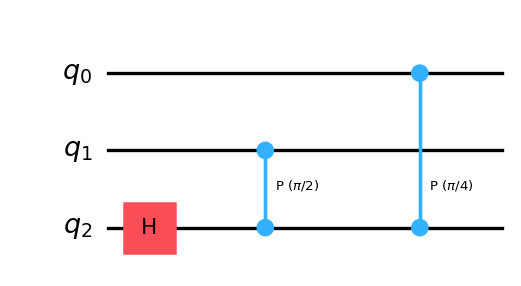

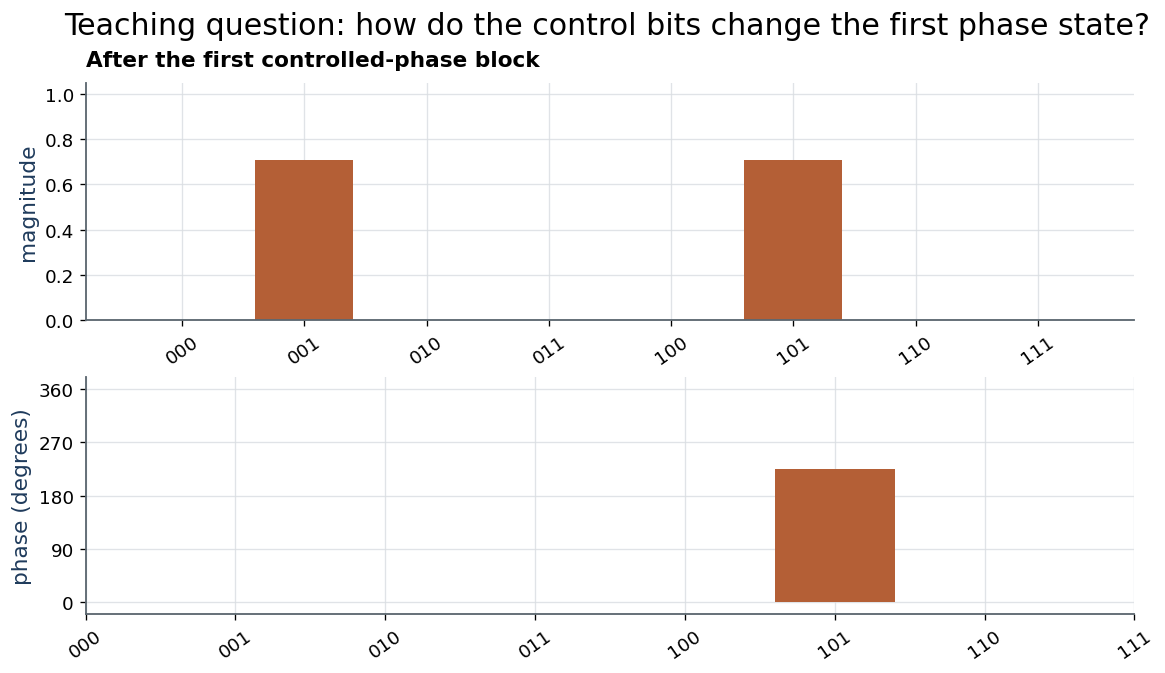

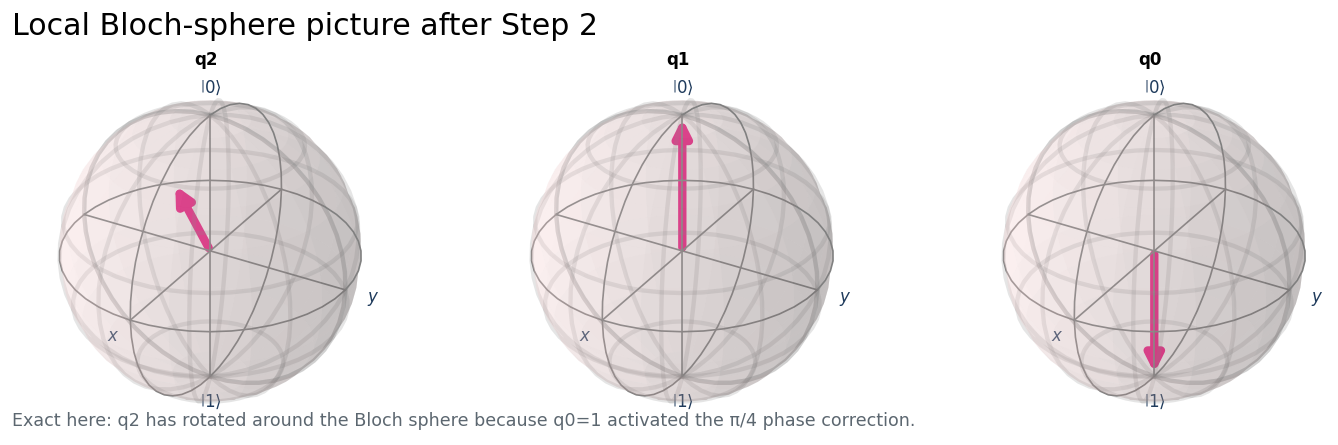

In [8]:
display(qc_step_2.draw('mpl'))

fig, axes = plt.subplots(2, 1, figsize=(9.6, 5.5), constrained_layout=True)
plot_state_magnitude_phase(axes[0], axes[1], states['step_2'].data, labels_3, color=COLORS['rust'], title='After the first controlled-phase block')
fig.suptitle('Teaching question: how do the control bits change the first phase state?', x=0.05, ha='left')
plt.show()

display_bloch_row(
    states['step_2'],
    title='Local Bloch-sphere picture after Step 2',
    exact_note='Exact here: q2 has rotated around the Bloch sphere because q0=1 activated the \u03c0/4 phase correction.'
)


> **Takeaway:** The controlled-phase gates do not change magnitudes here. They rotate the local phase state of $q_2$ by an angle determined by the input bits.


## 8. Step 3: Second Hadamard and Controlled-Phase Refinement

**Concept question:** How does the next qubit acquire its own phase state?

Next we process $q_1$.

Since the input bit there is $0$,
$$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}.
$$

Then the gate $\mathrm{cp}(\pi/2)$ from $q_0$ to $q_1$ contributes because $q_0 = 1$.

So the new factor on $q_1$ becomes
$$
\frac{|0\rangle + i|1\rangle}{\sqrt{2}}.
$$

The full state is now
$$
\frac{|0\rangle - e^{i\pi/4}|1\rangle}{\sqrt{2}}
\otimes
\frac{|0\rangle + i|1\rangle}{\sqrt{2}}
\otimes
|1\rangle.
$$

The shorter-angle and longer-angle phase refinements are now both visible in different qubits.


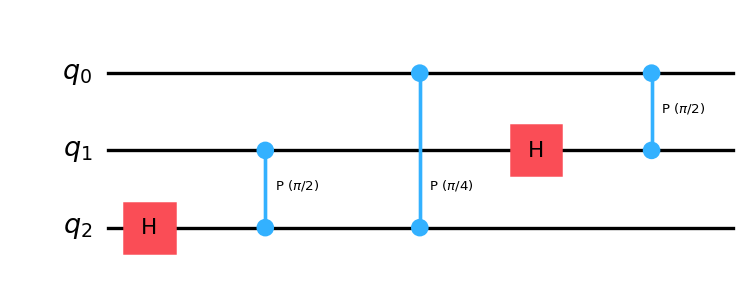

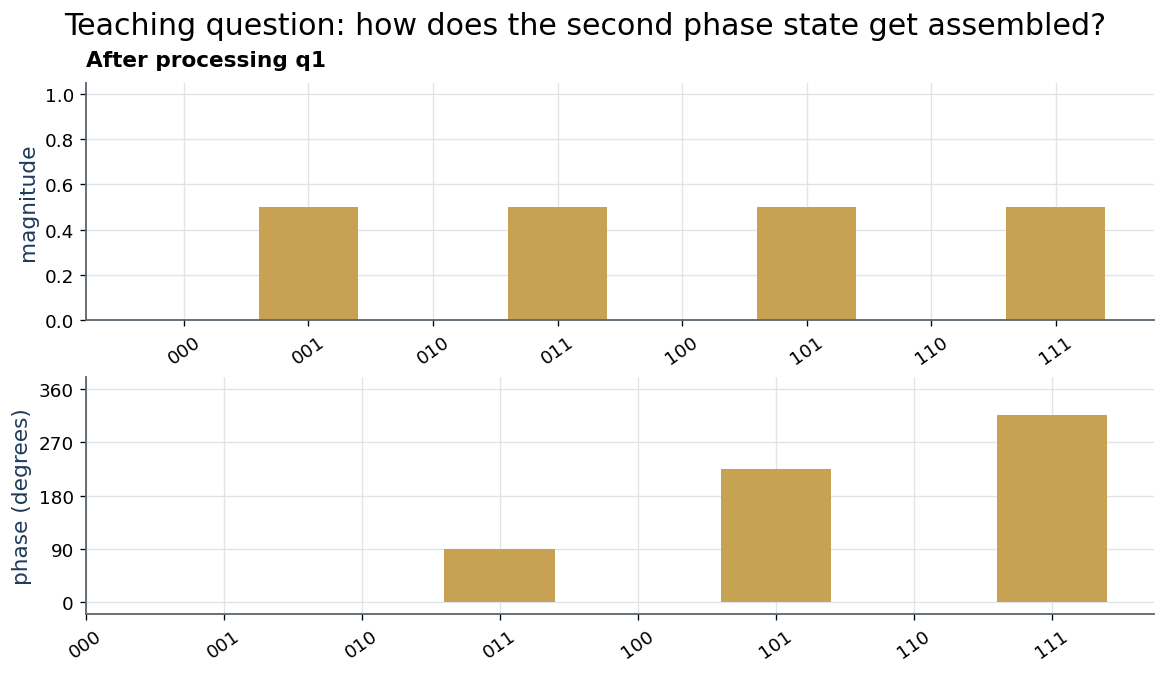

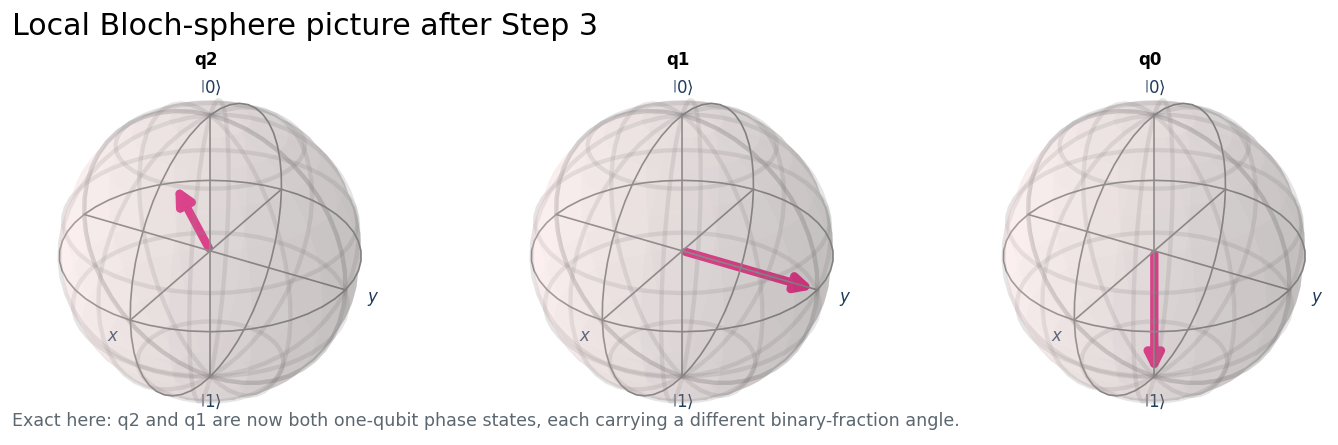

In [9]:
display(qc_step_3.draw('mpl'))

fig, axes = plt.subplots(2, 1, figsize=(9.6, 5.5), constrained_layout=True)
plot_state_magnitude_phase(axes[0], axes[1], states['step_3'].data, labels_3, color=COLORS['gold'], title='After processing q1')
fig.suptitle('Teaching question: how does the second phase state get assembled?', x=0.05, ha='left')
plt.show()

display_bloch_row(
    states['step_3'],
    title='Local Bloch-sphere picture after Step 3',
    exact_note='Exact here: q2 and q1 are now both one-qubit phase states, each carrying a different binary-fraction angle.'
)


> **Takeaway:** The QFT is building a tensor product of one-qubit phase states. Different qubits receive different binary-fraction phase refinements.


## 9. Step 4: The Final Hadamard

**Concept question:** What remains before the output ordering is fixed?

The last remaining qubit is $q_0$, which still holds the basis value $|1\rangle$. A final Hadamard gives
$$
|1\rangle \longrightarrow \frac{|0\rangle - |1\rangle}{\sqrt{2}}.
$$

So before the swap, the state is
$$
\frac{|0\rangle - e^{i\pi/4}|1\rangle}{\sqrt{2}}
\otimes
\frac{|0\rangle + i|1\rangle}{\sqrt{2}}
\otimes
\frac{|0\rangle - |1\rangle}{\sqrt{2}}.
$$

At this point the phase-state construction is complete. What remains is only to place the qubits in the conventional output order.


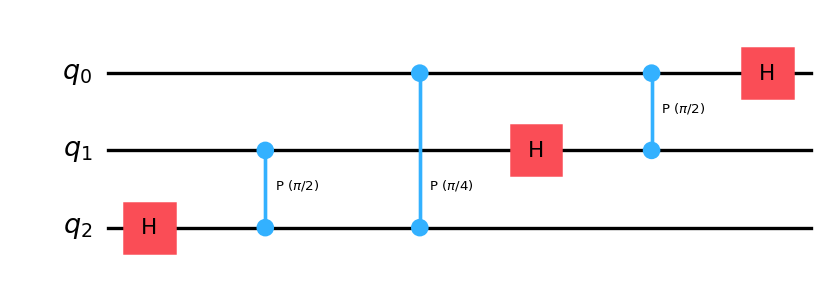

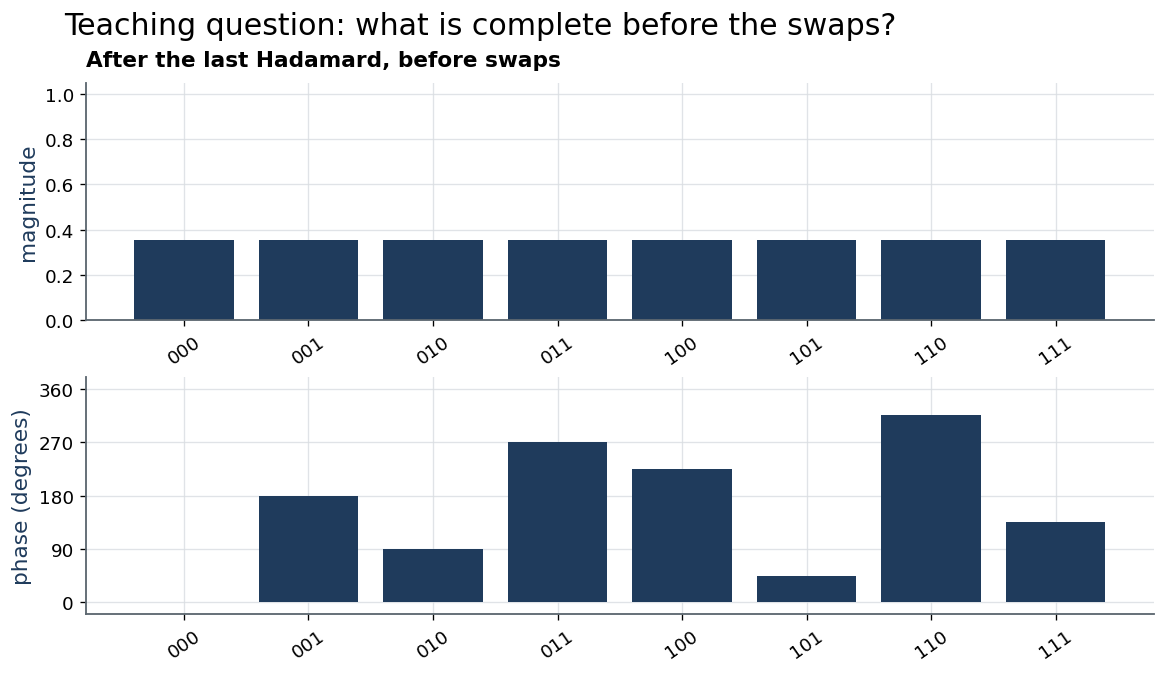

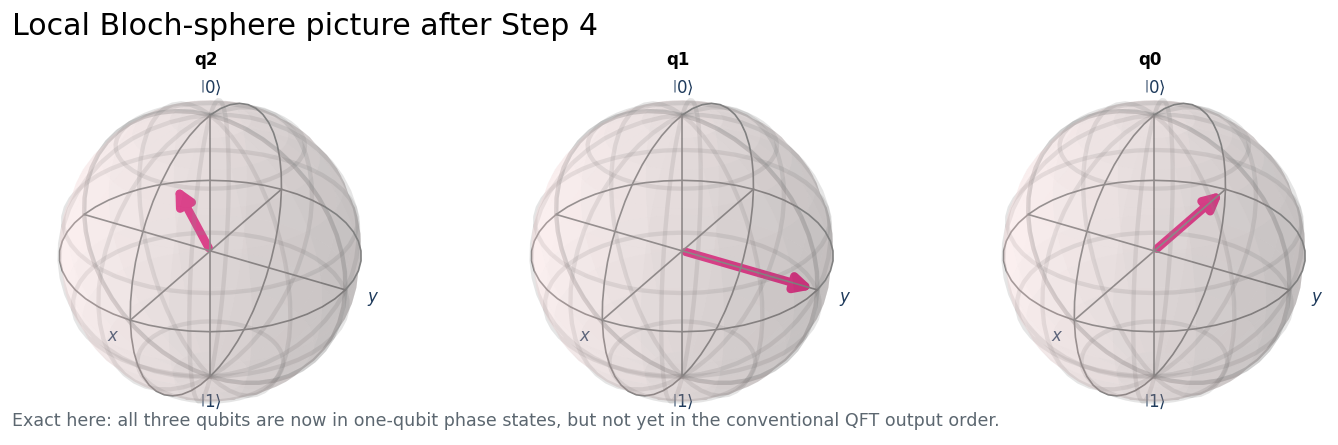

In [10]:
display(qc_step_4.draw('mpl'))

fig, axes = plt.subplots(2, 1, figsize=(9.6, 5.5), constrained_layout=True)
plot_state_magnitude_phase(axes[0], axes[1], states['step_4'].data, labels_3, color=COLORS['navy'], title='After the last Hadamard, before swaps')
fig.suptitle('Teaching question: what is complete before the swaps?', x=0.05, ha='left')
plt.show()

display_bloch_row(
    states['step_4'],
    title='Local Bloch-sphere picture after Step 4',
    exact_note='Exact here: all three qubits are now in one-qubit phase states, but not yet in the conventional QFT output order.'
)


> **Takeaway:** By the time the last Hadamard is done, the phase information is already present. The swap does not create new phase; it only fixes the register order.


## 10. Step 5: Swaps and Output Ordering

**Concept question:** Why are the final swaps not optional cosmetics?

Without the swap, the phase-state factors appear in reverse order relative to the conventional QFT output convention.

For our example, the pre-swap product form is
$$
\frac{|0\rangle - e^{i\pi/4}|1\rangle}{\sqrt{2}}
\otimes
\frac{|0\rangle + i|1\rangle}{\sqrt{2}}
\otimes
\frac{|0\rangle - |1\rangle}{\sqrt{2}}.
$$

After swapping $q_0$ and $q_2$, the ordered output becomes
$$
\frac{|0\rangle - |1\rangle}{\sqrt{2}}
\otimes
\frac{|0\rangle + i|1\rangle}{\sqrt{2}}
\otimes
\frac{|0\rangle - e^{i\pi/4}|1\rangle}{\sqrt{2}}.
$$

Same physics, different label order. That is why swaps matter whenever we want the circuit output to match the standard formula in the usual qubit order.


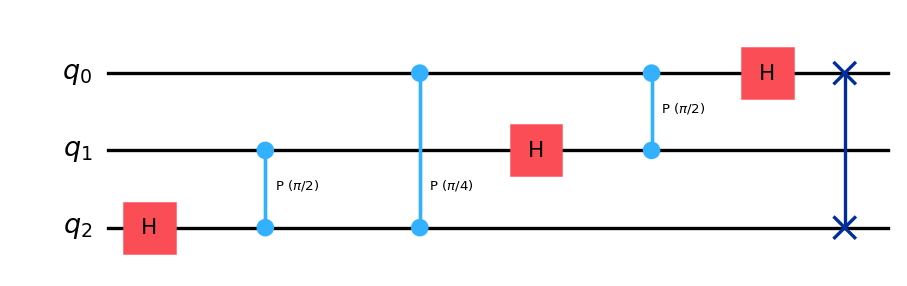

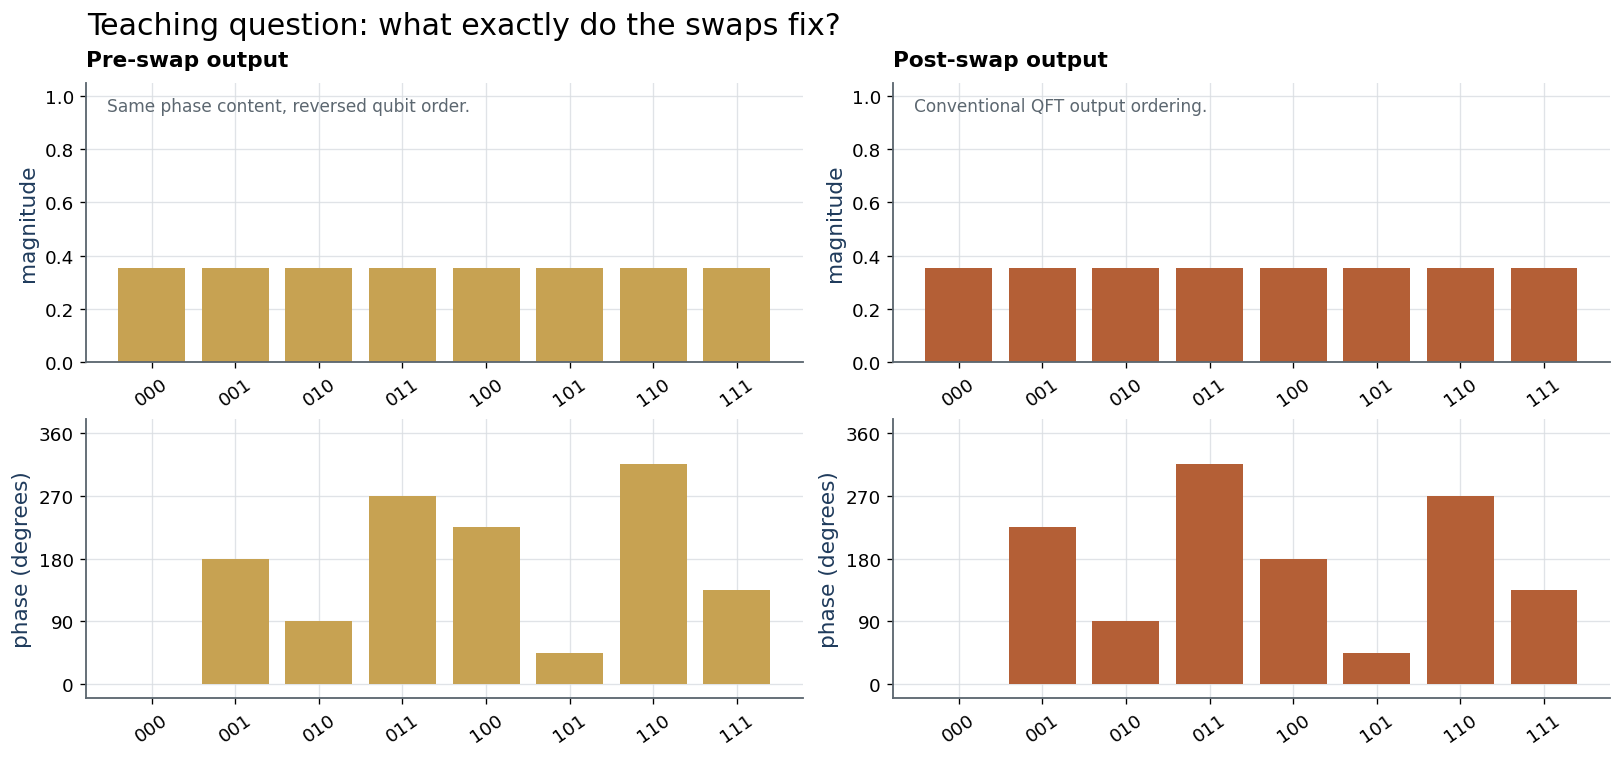

In [11]:
display(qc_step_5.draw('mpl'))

fig, axes = plt.subplots(2, 2, figsize=(13.4, 6.2), constrained_layout=True)
plot_state_magnitude_phase(axes[0, 0], axes[1, 0], states['step_4'].data, labels_3, color=COLORS['gold'], title='Pre-swap output')
plot_state_magnitude_phase(axes[0, 1], axes[1, 1], states['step_5'].data, labels_3, color=COLORS['rust'], title='Post-swap output')
axes[0, 0].text(0.03, 0.9, 'Same phase content, reversed qubit order.', transform=axes[0, 0].transAxes, fontsize=10.2, color=COLORS['gray'])
axes[0, 1].text(0.03, 0.9, 'Conventional QFT output ordering.', transform=axes[0, 1].transAxes, fontsize=10.2, color=COLORS['gray'])
fig.suptitle('Teaching question: what exactly do the swaps fix?', x=0.05, ha='left')
plt.show()


> **Takeaway:** The swaps do not change the transform itself. They align the wire order with the standard QFT output convention.


## 11. Bloch-Sphere Interpretation: What It Shows and What It Cannot Show

**Concept question:** When is the Bloch-sphere picture exact, and when is it only partial?

In the basis-state walkthrough above, the Bloch spheres were exact because the global state stayed a product of single-qubit phase states.

But that is not the general many-qubit situation.

If the global state becomes entangled, then a single Bloch sphere can at best represent a **reduced one-qubit state**. That reduced picture can still be useful, but it no longer contains the full multi-qubit information.

The example below uses a superposition input chosen so that the first controlled-phase block entangles qubits. The single-qubit Bloch vectors are now only local summaries.


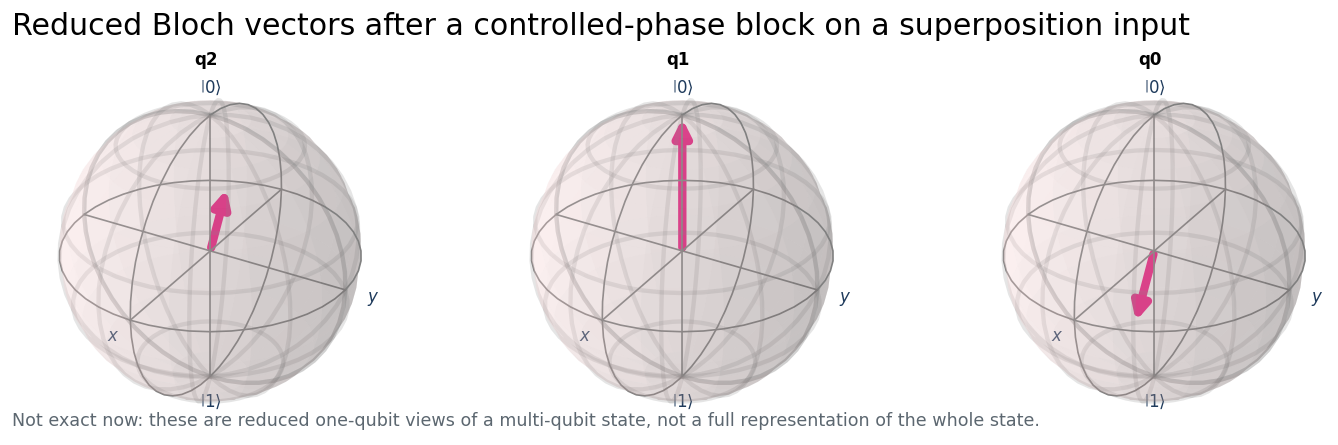

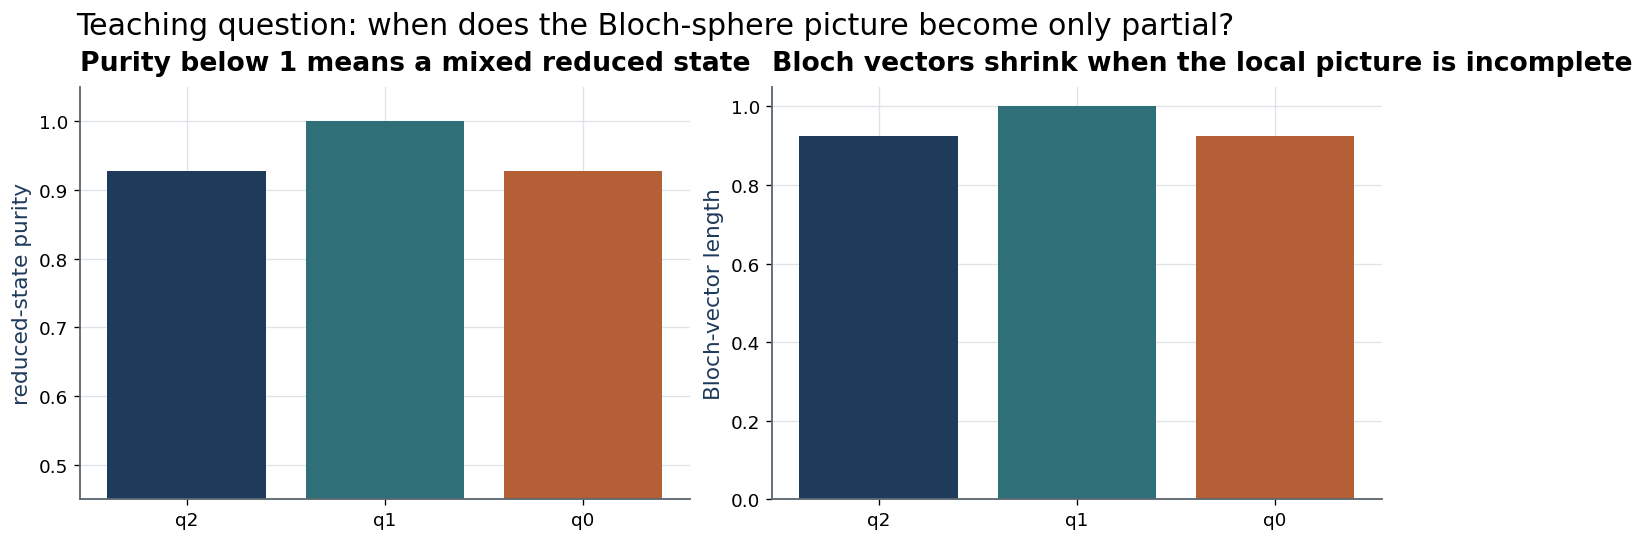

In [12]:
entangled_input = Statevector((basis_ket(3, 4) + basis_ket(3, 5)) / np.sqrt(2))
entangled_after_block = entangled_input.evolve(qc_step_2)

display_bloch_row(
    entangled_after_block,
    title='Reduced Bloch vectors after a controlled-phase block on a superposition input',
    exact_note='Not exact now: these are reduced one-qubit views of a multi-qubit state, not a full representation of the whole state.'
)

purities = [reduced_purity(entangled_after_block, qubit) for qubit in [2, 1, 0]]
bloch_lengths = [np.linalg.norm(bloch_xyz(entangled_after_block, qubit)) for qubit in [2, 1, 0]]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), constrained_layout=True)
axes[0].bar(['q2', 'q1', 'q0'], purities, color=[COLORS['navy'], COLORS['teal'], COLORS['rust']])
axes[0].set_ylim(0.45, 1.05)
axes[0].set_ylabel('reduced-state purity')
axes[0].set_title('Purity below 1 means a mixed reduced state', loc='left')

axes[1].bar(['q2', 'q1', 'q0'], bloch_lengths, color=[COLORS['navy'], COLORS['teal'], COLORS['rust']])
axes[1].set_ylim(0.0, 1.05)
axes[1].set_ylabel('Bloch-vector length')
axes[1].set_title('Bloch vectors shrink when the local picture is incomplete', loc='left')

fig.suptitle('Teaching question: when does the Bloch-sphere picture become only partial?', x=0.05, ha='left')
plt.show()


> **Common misconception:** A row of Bloch spheres is not a complete picture of a generic 3-qubit state. It is exact only for product states; otherwise it is a reduced local summary.


## 12. Full Worked Example for $|101\rangle$

**Concept question:** Can we see the whole evolution in one compact view without losing the logic?

Yes. The gallery below compresses the main evolution into five moments:
- the input basis state,
- after the first Hadamard,
- after the first controlled-phase block,
- after all Hadamards but before swaps,
- and after the final swap.

This is the visual arc of the whole lecture: basis label $\rightarrow$ local phase construction $\rightarrow$ ordered QFT output.


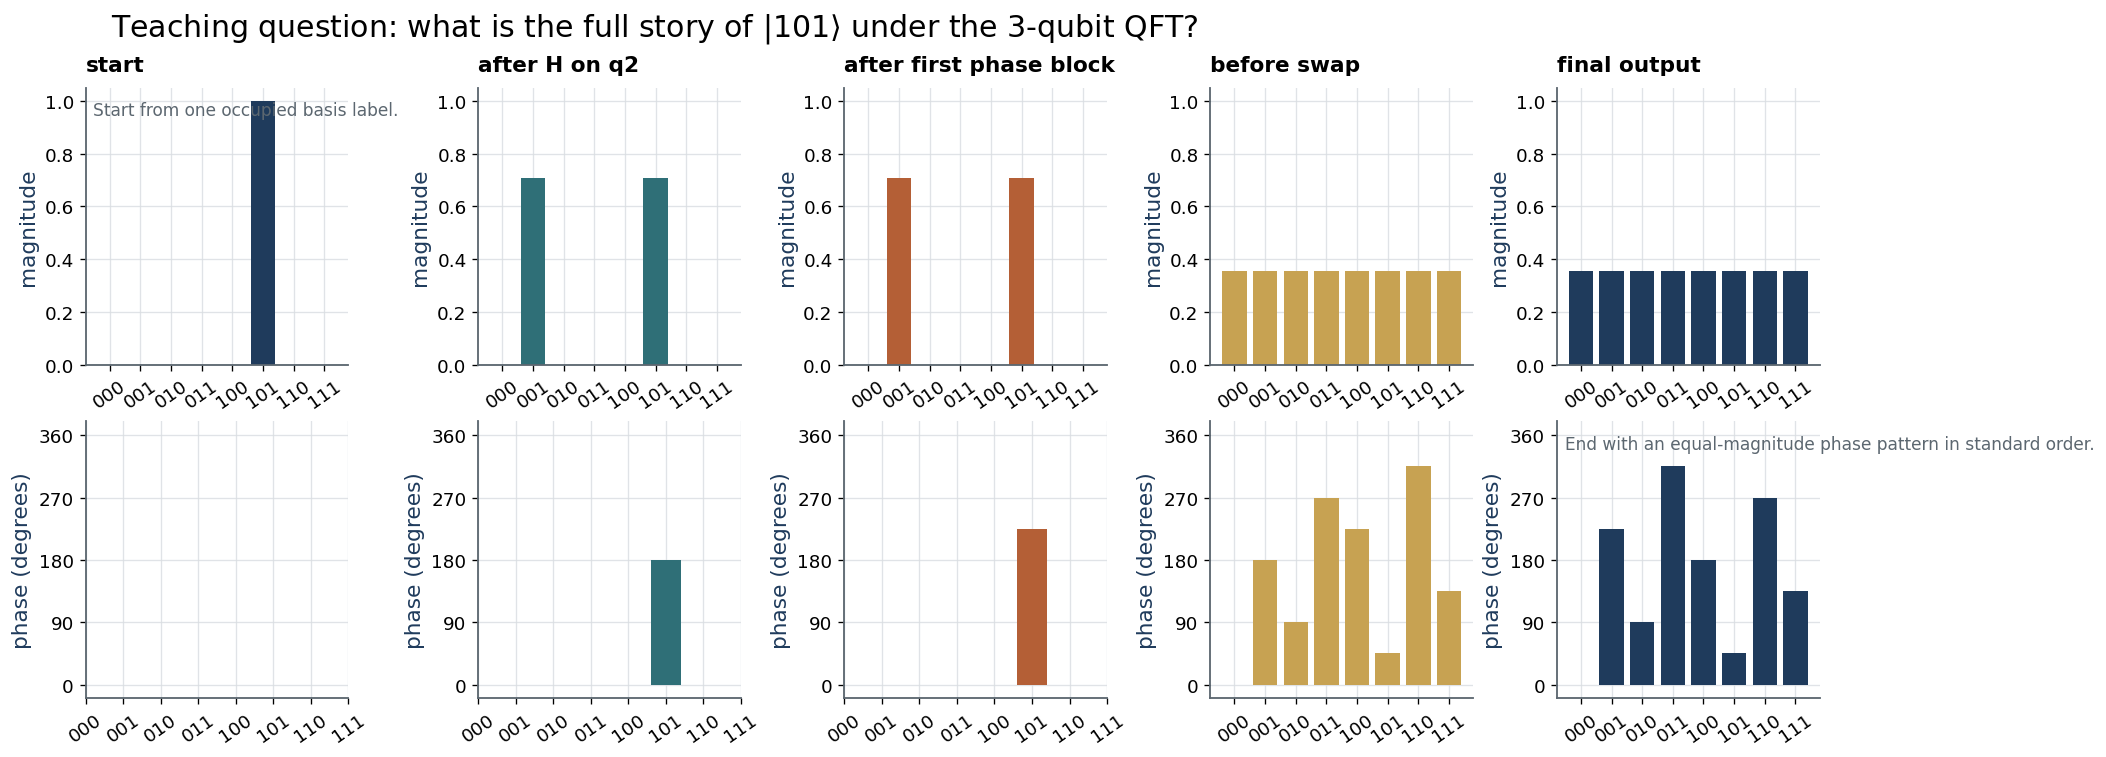

In [13]:
stage_specs = [
    ('start', states['start'], COLORS['navy']),
    ('after H on q2', states['step_1'], COLORS['teal']),
    ('after first phase block', states['step_2'], COLORS['rust']),
    ('before swap', states['step_4'], COLORS['gold']),
    ('final output', states['step_5'], COLORS['navy']),
]

fig, axes = plt.subplots(2, len(stage_specs), figsize=(17.4, 6.2), constrained_layout=True)

for column, (title, state, color) in enumerate(stage_specs):
    plot_state_magnitude_phase(axes[0, column], axes[1, column], state.data, labels_3, color=color, title=title)

axes[0, 0].text(0.03, 0.9, 'Start from one occupied basis label.', transform=axes[0, 0].transAxes, fontsize=10.2, color=COLORS['gray'])
axes[1, 4].text(0.03, 0.9, 'End with an equal-magnitude phase pattern in standard order.', transform=axes[1, 4].transAxes, fontsize=10.2, color=COLORS['gray'])

fig.suptitle(r'Teaching question: what is the full story of $|101\rangle$ under the 3-qubit QFT?', x=0.05, ha='left')
plt.show()


> **Takeaway:** The full worked example confirms the narrative: the QFT does not gradually “spread probability.” It gradually assembles a structured phase state.


## 13. Formula vs Manual Circuit vs Library Implementation

**Concept question:** Does the final state really agree across all three viewpoints?

It should, and this is the cleanest numerical check of the whole notebook.

We will compare the final state from:
- the direct matrix formula,
- the explicit manual circuit,
- the library implementation `QFTGate(3)`.

Agreement must be checked **up to global phase**, because statevectors that differ only by one overall phase represent the same physical state.


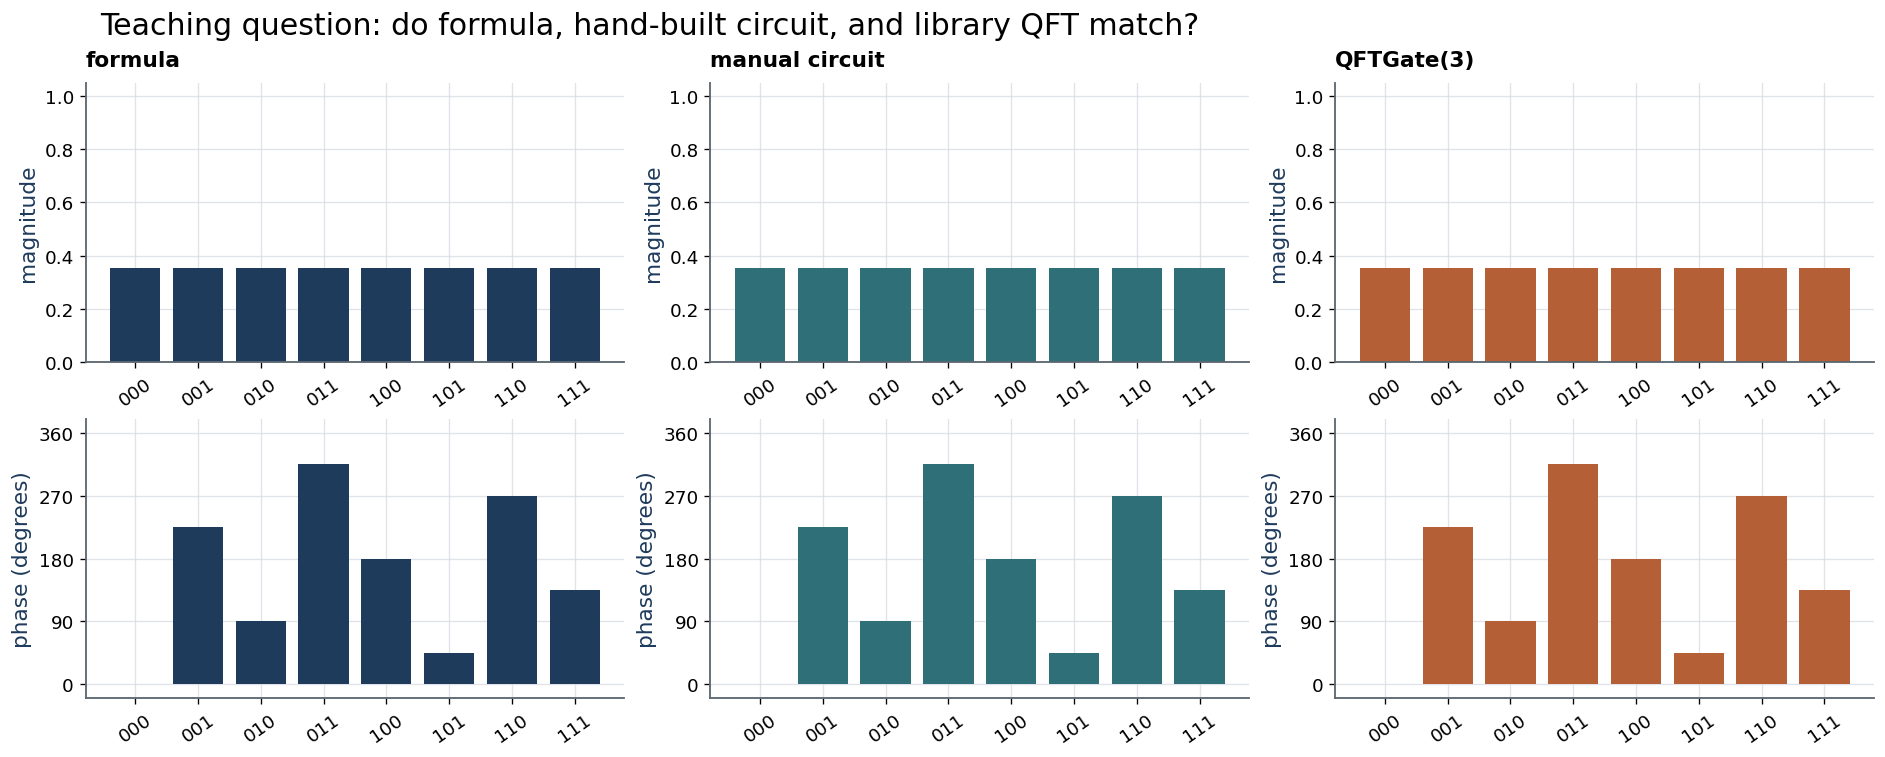

Formula vs manual fidelity:  1.000000000000
Formula vs library fidelity: 1.000000000000
Max amplitude error after global-phase alignment (manual):  1.04e-15
Max amplitude error after global-phase alignment (library): 8.44e-16


In [14]:
formula_state = Statevector(qft_matrix(3) @ worked_input_state.data)
manual_state = states['step_5']

library_qft_3 = QuantumCircuit(3, name='lib_QFT_3')
library_qft_3.append(QFTGate(3), range(3))
library_state = worked_input_state.evolve(library_qft_3)

aligned_manual = align_global_phase(formula_state.data, manual_state.data)
aligned_library = align_global_phase(formula_state.data, library_state.data)

manual_fidelity = np.abs(np.vdot(formula_state.data, manual_state.data)) ** 2
library_fidelity = np.abs(np.vdot(formula_state.data, library_state.data)) ** 2
manual_error = np.max(np.abs(aligned_manual - formula_state.data))
library_error = np.max(np.abs(aligned_library - formula_state.data))

fig, axes = plt.subplots(2, 3, figsize=(15.6, 6.2), constrained_layout=True)
plot_state_magnitude_phase(axes[0, 0], axes[1, 0], formula_state.data, labels_3, color=COLORS['navy'], title='formula')
plot_state_magnitude_phase(axes[0, 1], axes[1, 1], manual_state.data, labels_3, color=COLORS['teal'], title='manual circuit')
plot_state_magnitude_phase(axes[0, 2], axes[1, 2], library_state.data, labels_3, color=COLORS['rust'], title='QFTGate(3)')
fig.suptitle('Teaching question: do formula, hand-built circuit, and library QFT match?', x=0.05, ha='left')
plt.show()

print(f'Formula vs manual fidelity:  {manual_fidelity:.12f}')
print(f'Formula vs library fidelity: {library_fidelity:.12f}')
print(f'Max amplitude error after global-phase alignment (manual):  {manual_error:.2e}')
print(f'Max amplitude error after global-phase alignment (library): {library_error:.2e}')


> **Takeaway:** The explicit formula, the manual circuit, and the library implementation agree. The circuit is not a mnemonic; it really realizes the same transformation.


## 14. Common Misconceptions

- **“QFT is just a quantum FFT on classical samples.”**
  Not quite. The QFT acts on amplitude distributions in Hilbert space, and its central resource is structured relative phase.

- **“Equal magnitudes mean the output is simple.”**
  No. In QFT outputs, equal magnitudes can still hide highly structured phase patterns, and that phase ordering is often the main information.

- **“A Bloch sphere fully describes each step of the 3-qubit circuit.”**
  Only for product states. In general, a single Bloch sphere shows at most a reduced one-qubit view.

- **“The final swaps are cosmetic.”**
  They are not. They fix the output ordering so that the circuit matches the standard QFT convention.


## 15. Summary and Follow-Up Prompts

We used one 3-qubit example to reveal the full QFT pattern:
- a basis label becomes a structured phase ramp,
- Hadamards create the local phase-sensitive states,
- controlled-phase gates write binary-fraction phase corrections,
- the final swap restores the conventional output order,
- and the result matches the QFT formula exactly.

The Bloch sphere helped because our worked basis-state example stayed product-structured throughout the staged construction. That was a feature of the chosen input, not a general many-qubit fact.

> **Takeaway:** The 3-qubit QFT already shows the essence of the full transform: it is a compact circuit for writing computational-basis information into structured phase.

**Follow-up prompts**
- Compare the phase ramps for $|001\rangle$ and $|101\rangle$. Which qubit-local phases change, and by how much?
- Remove the final swap and reinterpret the output labels by hand. What changes, and what does not?
- Choose a superposition input and identify the first place where the Bloch-sphere picture becomes only a reduced local view.
- Starting from the final product-form state, explain why inverse QFT can decode phase structure back into computational-basis information.
